In [7]:
import torch
import torch.nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from google.colab import files

import matplotlib.pyplot as plt

# 1. Data Loading and Exploration

---



In [8]:
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"abdallahhashad0","key":"05c6ff01238092a48ae930db2d311076"}'}

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q -o intel-image-classification.zip -d intel_images

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
import os
for root, dirs, files_ in os.walk("intel_images"):
    print(root, len(files_), "files")
    if len(dirs) > 10:
        break

intel_images 0 files
intel_images/seg_test 0 files
intel_images/seg_test/seg_test 0 files
intel_images/seg_test/seg_test/street 501 files
intel_images/seg_test/seg_test/glacier 553 files
intel_images/seg_test/seg_test/buildings 437 files
intel_images/seg_test/seg_test/mountain 525 files
intel_images/seg_test/seg_test/sea 510 files
intel_images/seg_test/seg_test/forest 474 files
intel_images/seg_train 0 files
intel_images/seg_train/seg_train 0 files
intel_images/seg_train/seg_train/street 2382 files
intel_images/seg_train/seg_train/glacier 2404 files
intel_images/seg_train/seg_train/buildings 2191 files
intel_images/seg_train/seg_train/mountain 2512 files
intel_images/seg_train/seg_train/sea 2274 files
intel_images/seg_train/seg_train/forest 2271 files
intel_images/seg_pred 0 files
intel_images/seg_pred/seg_pred 7301 files


In [5]:
BATCH_SIZE = 32
SEED = 42
DEVICE = "cpu"

In [11]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor()
])

In [12]:
train_data = datasets.ImageFolder(root="intel_images/seg_train/seg_train", transform=train_transform)
test_data = datasets.ImageFolder(root="intel_images/seg_test/seg_test", transform=test_transform)

In [13]:
IMG,label = train_data[1]

In [14]:
IMG.shape

torch.Size([3, 150, 150])

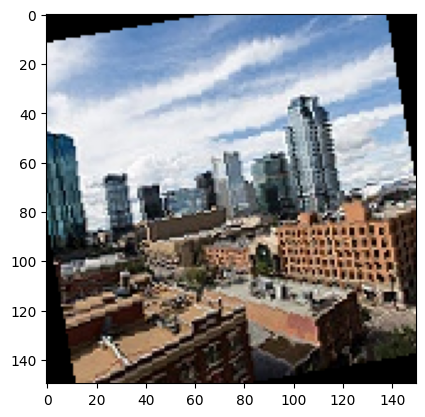

In [15]:
plt.imshow(IMG.permute(1,2,0))

In [16]:
class_names = train_data.classes
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [17]:
class_names_to_idx = train_data.class_to_idx
class_names_to_idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

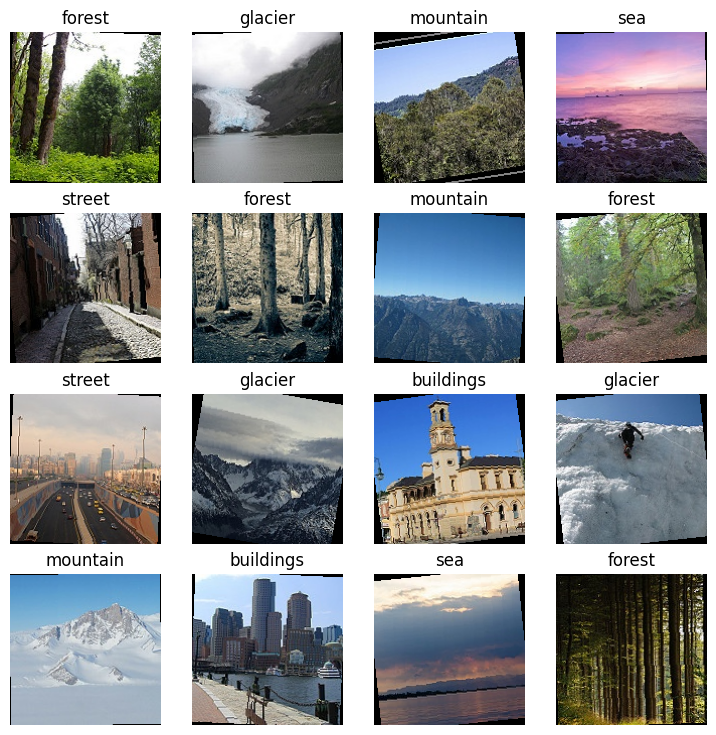

In [18]:
torch.manual_seed(SEED)
fig = plt.figure(figsize = (9,9))
rows,cols= 4,4
for i in range(1,rows*cols+1):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    img,label= train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis(False)

In [19]:
train_dataloader = DataLoader(dataset=train_data,batch_size = BATCH_SIZE,shuffle=True)
test_dataloader = DataLoader(dataset=test_data,batch_size = BATCH_SIZE,shuffle=False)

# 2. Building the Model Training and Evaluation Functions

In [20]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=DEVICE):
  train_loss,train_acc = 0,0
  model.train()
  for batch,(x,y) in enumerate(data_loader):
    x,y = x.to(device),y.to(device)
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [21]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              accuracy_fn,
              device:torch.device= DEVICE):
  test_loss,test_acc= 0,0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x,y = x.to(device),y.to(device)
      test_pred = model(x)
      loss = loss_fn(test_pred,y)
      test_loss += loss
      test_acc += accuracy_fn(y_true=y,y_pred= test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

In [22]:
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=DEVICE):
  loss,acc = 0,0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x,y = x.to(device),y.to(device)
      test_pred = model(x)
      loss += loss_fn(test_pred,y)
      acc += accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
    return {"Model_name":model.__class__.__name__,
            "Model_loss":loss.item(),
            "Model_ACC":acc}

In [23]:
def print_time(start:float,end:float,device:torch.device=DEVICE):
  total_time = end-start
  print(f"Time taken: {total_time:.3f} seconds on {device}")

In [24]:
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = correct/len(y_pred)*100
  return acc

# 3. Model0

In [25]:
from torch import nn

class Model0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [26]:
model_0 = Model0(input_shape= 3*150*150,
                 hidden_units = 20,
                 output_shape=len(class_names))

In [27]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)

### 3. Model0 Train&Test

In [28]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

In [29]:
torch.manual_seed(SEED)
time_start_model0 = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model = model_0,
             data_loader= train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
  test_step(model = model_0,
            data_loader= test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn = accuracy_fn,
            device = DEVICE)
time_end_model0 = timer()
total_time_model0 = print_time(time_start_model0,time_end_model0)
print(total_time_model0)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 1.46332 | Train accuracy: 43.82%
Test loss: 1.37911 | Test accuracy: 45.73%
Epoch: 1
Train loss: 1.32240 | Train accuracy: 49.33%
Test loss: 1.36259 | Test accuracy: 48.60%
Epoch: 2
Train loss: 1.30098 | Train accuracy: 50.93%
Test loss: 1.36439 | Test accuracy: 48.47%
Time taken: 66.780 seconds on cpu
None


In [30]:
model_0_result = eval_model(model = model_0,
             data_loader= train_dataloader,
             loss_fn = loss_fn,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
model_0_result

{'Model_name': 'Model0',
 'Model_loss': 1.3114104270935059,
 'Model_ACC': 50.19061629967097}

#4. Model1

In [31]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [32]:
class Model1(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape))
  def forward(self,x):
    return self.layer_stack(x)

In [33]:
model_1 = Model1(input_shape= 3*150*150,
                 hidden_units = 20,
                 output_shape=len(class_names)).to(DEVICE)

In [34]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [35]:
torch.manual_seed(SEED)
time_start_model0 = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model = model_1,
             data_loader= train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
  test_step(model = model_1,
            data_loader= test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn = accuracy_fn,
            device = DEVICE)
time_end_model0 = timer()
total_time_model0 = print_time(time_start_model0,time_end_model0,device = DEVICE)
print(total_time_model0)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 1.87891 | Train accuracy: 17.17%
Test loss: 1.79006 | Test accuracy: 18.38%
Epoch: 1
Train loss: 1.79155 | Train accuracy: 17.48%
Test loss: 1.79005 | Test accuracy: 17.45%
Epoch: 2
Train loss: 1.79159 | Train accuracy: 17.84%
Test loss: 1.79029 | Test accuracy: 17.45%
Time taken: 56.558 seconds on cuda
None


In [44]:
model_1_result = eval_model(model = model_1,
             data_loader= test_dataloader,
             loss_fn = loss_fn,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
model_1_result

{'Model_name': 'Model1',
 'Model_loss': 1.7902865409851074,
 'Model_ACC': 17.45345744680851}

#5. Model2

In [45]:
class Model2(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_stack_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_stack_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*18*18,
                      out_features=output_shape)
        )

    def forward(self, x):
        x = self.layer_stack(x)
        x = self.layer_stack_2(x)
        x = self.layer_stack_3(x)
        x = self.classifier(x)
        return x

In [46]:
model_2 = Model2(input_shape=3,
                 hidden_units = 20,
                 output_shape=len(class_names)).to(DEVICE)

In [47]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.001)

In [48]:
torch.manual_seed(SEED)
time_start_model2 = timer()

epochs = 15
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")
  train_step(model = model_2,
             data_loader= train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
  test_step(model = model_2,
            data_loader= test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn = accuracy_fn,
            device = DEVICE)
time_end_model2 = timer()
total_time_model2 = print_time(time_start_model2,time_end_model2,device = DEVICE)
print(total_time_model2)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0
Train loss: 1.21769 | Train accuracy: 50.60%
Test loss: 0.99988 | Test accuracy: 60.95%
Epoch: 1
Train loss: 0.87612 | Train accuracy: 65.58%
Test loss: 0.85048 | Test accuracy: 67.50%
Epoch: 2
Train loss: 0.74420 | Train accuracy: 71.76%
Test loss: 0.67743 | Test accuracy: 74.25%
Epoch: 3
Train loss: 0.66824 | Train accuracy: 74.75%
Test loss: 0.64271 | Test accuracy: 74.88%
Epoch: 4
Train loss: 0.61452 | Train accuracy: 76.86%
Test loss: 0.59172 | Test accuracy: 77.56%
Epoch: 5
Train loss: 0.56506 | Train accuracy: 78.93%
Test loss: 0.60831 | Test accuracy: 77.07%
Epoch: 6
Train loss: 0.52744 | Train accuracy: 80.71%
Test loss: 0.55323 | Test accuracy: 80.40%
Epoch: 7
Train loss: 0.50964 | Train accuracy: 81.38%
Test loss: 0.49446 | Test accuracy: 82.92%
Epoch: 8
Train loss: 0.48076 | Train accuracy: 82.34%
Test loss: 0.51149 | Test accuracy: 82.57%
Epoch: 9
Train loss: 0.45797 | Train accuracy: 83.27%
Test loss: 0.48816 | Test accuracy: 82.46%
Epoch: 10
Train loss: 0.43812 

In [49]:
model_2_result = eval_model(model = model_2,
             data_loader= test_dataloader,
             loss_fn = loss_fn,
             accuracy_fn=accuracy_fn,
             device = DEVICE)
model_2_result

{'Model_name': 'Model2',
 'Model_loss': 0.46290841698646545,
 'Model_ACC': 84.13120567375886}

In [51]:
import pandas as pd
compare_results = pd.DataFrame([model_0_result, model_1_result, model_2_result])
compare_results

,Model_name,Model_loss,Model_ACC
0,Model0,1.311410,50.190616
1,Model1,1.790287,17.453457
2,Model2,0.462908,84.131206


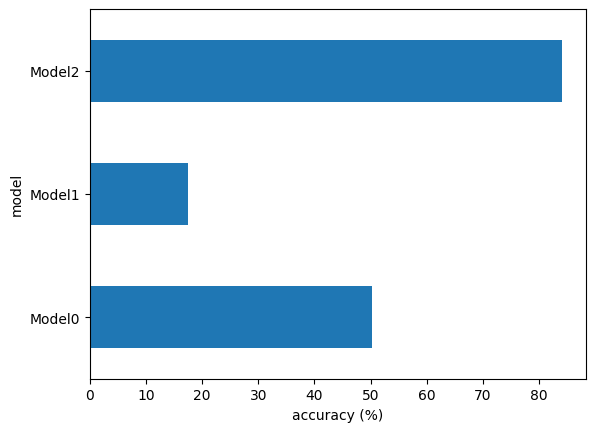

In [53]:
compare_results.set_index("Model_name")["Model_ACC"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

In [40]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "intel_model2_adam.pth"

torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to models/intel_model2_adam.pth


In [41]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>